In [9]:
# load lib
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
import numpy as np
import vectorbt as vbt
import pandas as pd
import numba as nb
import optuna # Import Optuna

# Add backend directory to path for importing app modules
import sys
from pathlib import Path
backend_path = Path(__file__).parent.parent / "backend" if "__file__" in dir() else Path("../backend").resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

from app.services.indicators import avwap_func_nb, atr_trailing_nb

In [ ]:
## Load datasource from deltalake and save it to local h5 file
# REMOTE_HOST = "http://192.168.1.30:9000"
REMOTE_HOST = "https://minio.phuchuynh.site"

from deltalake import DeltaTable
def load_stock_data() -> pd.DataFrame:
    """Load stock data from delta lake, ensuring index uniqueness to avoid unstack ValueError"""
    try:
        from deltalake import DeltaTable
        storage_options = {
            "AWS_ACCESS_KEY_ID": "CzOwnLkEDXQy951AOqes",
            "AWS_SECRET_ACCESS_KEY": "fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S",
            "AWS_ENDPOINT_URL": REMOTE_HOST,
            "AWS_ALLOW_HTTP": "true",
            "AWS_EC2_METADATA_DISABLED": "true",
            "AWS_REGION": 'us-east-1',
            "aws_conditional_put": "etag",
        }        
        dt = DeltaTable("s3://delta-table-storage/stocks", storage_options=storage_options)

        # Get data for last 2 years
        # Load watchlist symbols from CSV
        watchlist_path = "../backend/models/watchlist.csv"
        watchlist_df = pd.read_csv(watchlist_path)
        watchlist_symbols = watchlist_df.iloc[:, 0].values

        now = pd.Timestamp.now()
        start_date = now - pd.DateOffset(years=10)
        # Load all, then filter
        df = dt.to_pandas(
            filters=[("date", ">=", start_date), ("symbol", "in", watchlist_symbols)], 
            columns=["symbol", "date", "close", "open", "high", "low", "volume"]
        )
        
        # Remove duplicate (date, symbol) rows by keeping the last occurrence
        df = df.drop_duplicates(subset=["date", "symbol"], keep="last")
        # Convert to the same format as H5 store
        df = df.set_index(["date", "symbol"])
        stocks = df.unstack(level=1).bfill().ffill()
        
        print("Successfully loaded data from delta lake")
        return stocks
        
    except Exception as e:
        print(f"Error loading from delta lake: {e}")
        raise

import os
import pandas as pd

local_file = "stocks_data_latest.h5"
store_key = "stocks"

if os.path.exists(local_file):
    print(f"Loading stock data from local HDF5 file: {local_file}")
    with pd.HDFStore(local_file, mode="r") as store:
        df = store[store_key]
else:
    print("Local HDF5 file not found, loading stock data from Delta Lake...")
    df = load_stock_data()
    with pd.HDFStore(local_file, mode="w") as store:
        store.put(store_key, df)
    print(f"Stock data saved to {local_file}")

# Filter df to keep only columns for symbols in the watchlist (once)
watchlist_path = "../backend/models/watchlist.csv"
watchlist_df = pd.read_csv(watchlist_path)
watchlist_symbols = watchlist_df.iloc[:, 0].values
df = df.loc[:, df.columns.get_level_values('symbol').isin(watchlist_symbols)]
df


Loading stock data from local HDF5 file: stocks_data_latest.h5


close                                                        \
symbol           AAA        ABB        ACB        ACV       ADS        AGG   
date                                                                         
2016-01-29  6.892738   8.201591   3.635365  20.629999  3.940815  15.284813   
2016-02-01  7.196829   8.201591   3.616231  20.629999  3.940815  15.284813   
2016-02-02  7.298193   8.201591   3.635365  20.629999  3.940815  15.284813   
2016-02-03  7.196829   8.201591   3.635365  20.629999  3.940815  15.284813   
2016-02-04  7.247511   8.201591   3.635365  20.629999  3.940815  15.284813   
...              ...        ...        ...        ...       ...        ...   
2026-01-21  7.970000  14.300000  24.850000  59.799999  8.240000  14.650000   
2026-01-22  8.110000  14.100000  24.850000  60.400002  8.220000  15.150000   
2026-01-23  8.000000  14.200000  25.049999  59.400002  8.300000  14.700000   
2026-01-26  7.810000  13.900000  24.799999  53.400002  8.220000  14.650000   
2026-01-27  7.800000  13.800000  24.700001  51.200001  8.150000  14.500000   

                                                       ...        volume  \
symbol            AGR        ANV        APH       ASM  ...       VNINDEX   
date                                                   ...                 
2016-01-29   2.744280  17.299999  30.166281  8.001494  ...  9.877289e+07   
2016-02-01   2.744280  17.299999  30.166281  7.954974  ...  9.151639e+07   
2016-02-02   2.561327  17.299999  30.166281  7.861933  ...  8.205790e+07   
2016-02-03   2.652804  17.299999  30.166281  7.861933  ...  7.248801e+07   
2016-02-04   2.561327  17.299999  30.166281  7.954974  ...  5.899160e+07   
...               ...        ...        ...       ...  ...           ...   
2026-01-21  16.150000  26.200001   6.440000  6.410000  ...  1.186887e+09   
2026-01-22  16.350000  26.799999   6.470000  6.440000  ...  9.453971e+08   
2026-01-23  16.250000  26.900000   6.390000  6.380000  ...  8.795579e+08   
2026-01-26  15.900000  27.150000   6.300000  6.270000  ...  1.102434e+09   
2026-01-27  15.950000  26.700001   6.300000  6.150000  ...  7.826771e+08   

                                                                    \
symbol             VNM        VOS         VPB       VPG        VPI   
date                                                                 
2016-01-29    178270.0    11700.0  58299312.0    5000.0     5000.0   
2016-02-01    865310.0     7000.0  58299312.0    5000.0     5000.0   
2016-02-02    251520.0     1730.0  58299312.0    5000.0     5000.0   
2016-02-03    269870.0     2030.0  58299312.0    5000.0     5000.0   
2016-02-04    257320.0    70230.0  58299312.0    5000.0     5000.0   
...                ...        ...         ...       ...        ...   
2026-01-21  11234100.0  1343000.0  34082700.0  205800.0  2018800.0   
2026-01-22   8055200.0  4522500.0  19795300.0   97700.0  1522200.0   
2026-01-23  16050400.0  3865500.0  31092900.0  134200.0  1268600.0   
2026-01-26   8864800.0  2987900.0  32470600.0   74600.0  1128700.0   
2026-01-27   8357800.0  1986600.0   7349400.0  136600.0  1404300.0   

                                                          
symbol             VRE         VSC        VTP        YEG  
date                                                      
2016-01-29       800.0    107040.0      300.0     6100.0  
2016-02-01       800.0    702150.0      300.0     6100.0  
2016-02-02       800.0    251650.0      300.0     6100.0  
2016-02-03       800.0    121570.0      300.0     6100.0  
2016-02-04       800.0    202610.0      300.0     6100.0  
...                ...         ...        ...        ...  
2026-01-21   6966700.0  16271000.0  1228500.0  4410300.0  
2026-01-22   7252900.0   8567000.0  1317800.0  2965300.0  
2026-01-23   7919100.0   9390200.0  1410100.0  2026800.0  
2026-01-26   6004100.0  12339600.0  1131100.0  1618300.0  
2026-01-27  10746100.0   5417100.0   815700.0   727900.0  

[2498 rows x 990 columns]

In [5]:
## Breakout strategy
df.close = df.close.round(2)
# Create writable copies of price data to avoid read-only array errors in vectorbt
close = df.close.copy()
high = df.high.copy()
low = df.low.copy()

@nb.njit(cache=True)
def demarker_nb(high: np.ndarray, low: np.ndarray, length: int = 14) -> np.ndarray:
    """DeMarker indicator - Numba optimized version.
    
    Args:
        high: 1D or 2D array of high prices
        low: 1D or 2D array of low prices  
        length: lookback period for SMA
        
    Returns:
        DeMarker values (same shape as input)
    """
    n = high.shape[0]
    
    # Handle 1D case
    if high.ndim == 1:
        demax = np.zeros(n, dtype=np.float64)
        demin = np.zeros(n, dtype=np.float64)
        dem = np.full(n, np.nan, dtype=np.float64)
        
        # Calculate DeMax and DeMin
        for i in range(1, n):
            if high[i] > high[i-1]:
                demax[i] = high[i] - high[i-1]
            if low[i] < low[i-1]:
                demin[i] = low[i-1] - low[i]
        
        # Calculate rolling SMA and DeMarker
        for i in range(length - 1, n):
            demax_sum = 0.0
            demin_sum = 0.0
            for j in range(length):
                demax_sum += demax[i - j]
                demin_sum += demin[i - j]
            
            demax_sma = demax_sum / length
            demin_sma = demin_sum / length
            denom = demax_sma + demin_sma
            
            if denom != 0:
                dem[i] = demax_sma / denom
        
        return dem
    
    # Handle 2D case (multiple columns)
    else:
        m = high.shape[1]
        dem = np.full((n, m), np.nan, dtype=np.float64)
        
        for col in range(m):
            demax = np.zeros(n, dtype=np.float64)
            demin = np.zeros(n, dtype=np.float64)
            
            for i in range(1, n):
                if high[i, col] > high[i-1, col]:
                    demax[i] = high[i, col] - high[i-1, col]
                if low[i, col] < low[i-1, col]:
                    demin[i] = low[i-1, col] - low[i, col]
            
            for i in range(length - 1, n):
                demax_sum = 0.0
                demin_sum = 0.0
                for j in range(length):
                    demax_sum += demax[i - j]
                    demin_sum += demin[i - j]
                
                demax_sma = demax_sum / length
                demin_sma = demin_sum / length
                denom = demax_sma + demin_sma
                
                if denom != 0:
                    dem[i, col] = demax_sma / denom
        
        return dem


@nb.njit(cache=True)
def bollinger_squeeze_demarker_nb(
    high: np.ndarray, 
    low: np.ndarray, 
    close: np.ndarray,
    demarker_period: int = 14,
    keltner_period: int = 20,
    bb_period: int = 20,
    bb_deviation: float = 2.0,
    keltner_factor: float = 1.5) -> tuple:
    """
    Bollinger Squeeze with DeMarker indicator - Numba optimized.
    
    Based on MQL5 indicator logic:
    - When Bollinger Bands are inside Keltner Channel = Squeeze ON (sideways)
    - When Bollinger Bands are outside Keltner Channel = Squeeze OFF (trending)
    - DeMarker oscillator determines direction
    
    Args:
        high: High prices (2D array: rows=time, cols=symbols)
        low: Low prices
        close: Close prices
        demarker_period: Period for DeMarker
        keltner_period: Period for ATR (Keltner width)
        bb_period: Period for Bollinger Bands StdDev
        bb_deviation: Bollinger Bands deviation multiplier
        keltner_factor: Keltner Channel ATR multiplier
        
    Returns:
        tuple of (histo_trending, histo_sideways, histo_line, squeeze_on, direction)
        - histo_trending: Histogram value when NOT in squeeze (0 when in squeeze)
        - histo_sideways: Histogram value when IN squeeze (0 when not)
        - histo_line: Raw DeMarker centered value (DeM - 0.5)
        - squeeze_on: Boolean array (True = squeeze is on, consolidation)
        - direction: 1 = bullish, -1 = bearish
    """
    n = high.shape[0]
    m = high.shape[1] if high.ndim > 1 else 1
    
    # Reshape 1D to 2D for uniform processing
    if high.ndim == 1:
        high = high.reshape(-1, 1)
        low = low.reshape(-1, 1)
        close = close.reshape(-1, 1)
    
    # Output arrays
    histo_trending = np.zeros((n, m), dtype=np.float64)
    histo_sideways = np.zeros((n, m), dtype=np.float64)
    histo_line = np.full((n, m), np.nan, dtype=np.float64)
    squeeze_on = np.zeros((n, m), dtype=np.bool_)
    direction = np.zeros((n, m), dtype=np.int8)
    
    max_period = max(demarker_period, keltner_period, bb_period)
    
    for col in range(m):
        # ========== Calculate DeMarker ==========
        demax = np.zeros(n, dtype=np.float64)
        demin = np.zeros(n, dtype=np.float64)
        dem = np.full(n, np.nan, dtype=np.float64)
        
        for i in range(1, n):
            if high[i, col] > high[i-1, col]:
                demax[i] = high[i, col] - high[i-1, col]
            if low[i, col] < low[i-1, col]:
                demin[i] = low[i-1, col] - low[i, col]
        
        for i in range(demarker_period - 1, n):
            demax_sum = 0.0
            demin_sum = 0.0
            for j in range(demarker_period):
                demax_sum += demax[i - j]
                demin_sum += demin[i - j]
            denom = demax_sum + demin_sum
            if denom != 0:
                dem[i] = demax_sum / denom
        
        # ========== Calculate ATR (True Range) ==========
        tr = np.zeros(n, dtype=np.float64)
        atr = np.full(n, np.nan, dtype=np.float64)
        
        for i in range(1, n):
            hl = high[i, col] - low[i, col]
            hc = abs(high[i, col] - close[i-1, col])
            lc = abs(low[i, col] - close[i-1, col])
            tr[i] = max(hl, hc, lc)
        
        # SMA of TR for ATR
        for i in range(keltner_period, n):
            atr_sum = 0.0
            for j in range(keltner_period):
                atr_sum += tr[i - j]
            atr[i] = atr_sum / keltner_period
        
        # ========== Calculate StdDev (for Bollinger Bands) ==========
        stddev = np.full(n, np.nan, dtype=np.float64)
        
        for i in range(bb_period - 1, n):
            # Calculate SMA
            sma = 0.0
            for j in range(bb_period):
                sma += close[i - j, col]
            sma /= bb_period
            
            # Calculate StdDev
            var_sum = 0.0
            for j in range(bb_period):
                diff = close[i - j, col] - sma
                var_sum += diff * diff
            stddev[i] = np.sqrt(var_sum / bb_period)
        
        # ========== Calculate Squeeze & Histogram ==========
        for i in range(max_period, n):
            if np.isnan(dem[i]) or np.isnan(atr[i]) or np.isnan(stddev[i]):
                continue
            
            # d = DeMarker centered around 0 (range -0.5 to +0.5)
            d = dem[i] - 0.5
            histo_line[i, col] = d
            
            # Keltner width
            keltner_width = atr[i] * keltner_factor
            
            # Bollinger width (BB deviation * stddev)
            bb_width = bb_deviation * stddev[i]
            
            # Squeeze ratio: if < 1, BB inside Keltner (squeeze ON)
            if keltner_width > 0:
                bbs = bb_width / keltner_width
            else:
                bbs = 1.0
            
            if bbs < 1.0:
                # Squeeze is ON (consolidation/sideways)
                squeeze_on[i, col] = True
                histo_sideways[i, col] = d
                histo_trending[i, col] = 0.0
            else:
                # Squeeze is OFF (trending)
                squeeze_on[i, col] = False
                histo_trending[i, col] = d
                histo_sideways[i, col] = 0.0
            
            # Direction: 1 = bullish (d > 0), -1 = bearish (d < 0)
            if d > 0:
                direction[i, col] = 1
            else:
                direction[i, col] = -1
    
    return histo_trending, histo_sideways, histo_line, squeeze_on, direction


def bollinger_squeeze_demarker(
    high, low, close,
    demarker_period: int = 14,
    keltner_period: int = 20,
    bb_period: int = 20,
    bb_deviation: float = 2.0,
    keltner_factor: float = 1.5):
    """
    Bollinger Squeeze with DeMarker - Wrapper for DataFrame/Series.
    
    Returns dict with:
        - histo_trending: Histogram when trending (squeeze OFF)
        - histo_sideways: Histogram when sideways (squeeze ON)  
        - histo_line: Raw DeMarker value centered (-0.5 to +0.5)
        - squeeze_on: Boolean, True when in squeeze
        - direction: 1=bullish, -1=bearish
    """
    is_df = isinstance(high, pd.DataFrame)
    is_series = isinstance(high, pd.Series)
    
    if is_df:
        idx, cols = high.index, high.columns
        high_arr = high.values.astype(np.float64)
        low_arr = low.values.astype(np.float64)
        close_arr = close.values.astype(np.float64)
    elif is_series:
        idx = high.index
        high_arr = high.values.astype(np.float64)
        low_arr = low.values.astype(np.float64)
        close_arr = close.values.astype(np.float64)
    else:
        high_arr = high.astype(np.float64)
        low_arr = low.astype(np.float64)
        close_arr = close.astype(np.float64)
    
    trending, sideways, line, squeeze, direction = bollinger_squeeze_demarker_nb(
        high_arr, low_arr, close_arr,
        demarker_period, keltner_period, bb_period, bb_deviation, keltner_factor
    )
    
    if is_df:
        return {
            'histo_trending': pd.DataFrame(trending, index=idx, columns=cols),
            'histo_sideways': pd.DataFrame(sideways, index=idx, columns=cols),
            'histo_line': pd.DataFrame(line, index=idx, columns=cols),
            'squeeze_on': pd.DataFrame(squeeze, index=idx, columns=cols),
            'direction': pd.DataFrame(direction, index=idx, columns=cols),
        }
    elif is_series:
        return {
            'histo_trending': pd.Series(trending.flatten(), index=idx, name='histo_trending'),
            'histo_sideways': pd.Series(sideways.flatten(), index=idx, name='histo_sideways'),
            'histo_line': pd.Series(line.flatten(), index=idx, name='histo_line'),
            'squeeze_on': pd.Series(squeeze.flatten(), index=idx, name='squeeze_on'),
            'direction': pd.Series(direction.flatten(), index=idx, name='direction'),
        }
    else:
        return {
            'histo_trending': trending,
            'histo_sideways': sideways,
            'histo_line': line,
            'squeeze_on': squeeze,
            'direction': direction,
        }


demarker_period = 20
keltner_period = 20
bb_period = 20
bb_deviation = 2.0
keltner_factor = 1.5
atr_multiplier = 1.0
sl_stop = 0.1
    
# Calculate indicator
bb_demarker = bollinger_squeeze_demarker(
    high, low, close,
    demarker_period=demarker_period,
    keltner_period=keltner_period,
    bb_period=bb_period,
    bb_deviation=bb_deviation,
    keltner_factor=keltner_factor
)

# Buy signal: squeeze just ended + bullish direction
buy_signal = (
    (bb_demarker['squeeze_on'].shift(1) & ~bb_demarker['squeeze_on']) &
    (bb_demarker['direction'] == 1)
)

# Exit signal: ATR trailing stop
atr_indicator = vbt.IndicatorFactory.from_talib("ATR").run(high, low, close, timeperiod=10)
atr_scope = atr_indicator.real
atr_trailing_indicator = vbt.IndicatorFactory(
    input_names=['close', 'atr'],
    param_names=['atr_multiplier'],
    output_names=['atr_trailing']
).from_apply_func(atr_trailing_nb)
atr_sl = atr_trailing_indicator.run(close, atr_scope, atr_multiplier=1.8)
exit1 = close.vbt.crossed_below(atr_sl.atr_trailing)
sell_signal = exit1

# Create portfolio
pf = vbt.Portfolio.from_signals(
    close=close,
    entries=buy_signal,
    exits=sell_signal,
    freq='1d',
    group_by=['symbol'],
    cash_sharing=False,
    sl_stop=sl_stop,
)

# Calculate Sharpe ratios
sharpe_ratios = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
sharpe_ratios

symbol
AAA       0.364826
ABB       0.326874
ACB       0.269415
ACV       0.989095
ADS       0.476963
            ...   
VPI       0.276648
VRE       0.413611
VSC       1.039767
VTP       0.546923
YEG       0.864130
Name: sharpe_ratio, Length: 197, dtype: float64

In [ ]:
## Breakout strategy
df.close = df.close.round(2)
# Create writable copies of price data to avoid read-only array errors in vectorbt
close = df.close.copy()
high = df.high.copy()
low = df.low.copy()

@nb.njit(cache=True)
def demarker_nb(high: np.ndarray, low: np.ndarray, length: int = 14) -> np.ndarray:
    """DeMarker indicator - Numba optimized version.
    
    Args:
        high: 1D or 2D array of high prices
        low: 1D or 2D array of low prices  
        length: lookback period for SMA
        
    Returns:
        DeMarker values (same shape as input)
    """
    n = high.shape[0]
    
    # Handle 1D case
    if high.ndim == 1:
        demax = np.zeros(n, dtype=np.float64)
        demin = np.zeros(n, dtype=np.float64)
        dem = np.full(n, np.nan, dtype=np.float64)
        
        # Calculate DeMax and DeMin
        for i in range(1, n):
            if high[i] > high[i-1]:
                demax[i] = high[i] - high[i-1]
            if low[i] < low[i-1]:
                demin[i] = low[i-1] - low[i]
        
        # Calculate rolling SMA and DeMarker
        for i in range(length - 1, n):
            demax_sum = 0.0
            demin_sum = 0.0
            for j in range(length):
                demax_sum += demax[i - j]
                demin_sum += demin[i - j]
            
            demax_sma = demax_sum / length
            demin_sma = demin_sum / length
            denom = demax_sma + demin_sma
            
            if denom != 0:
                dem[i] = demax_sma / denom
        
        return dem
    
    # Handle 2D case (multiple columns)
    else:
        m = high.shape[1]
        dem = np.full((n, m), np.nan, dtype=np.float64)
        
        for col in range(m):
            demax = np.zeros(n, dtype=np.float64)
            demin = np.zeros(n, dtype=np.float64)
            
            for i in range(1, n):
                if high[i, col] > high[i-1, col]:
                    demax[i] = high[i, col] - high[i-1, col]
                if low[i, col] < low[i-1, col]:
                    demin[i] = low[i-1, col] - low[i, col]
            
            for i in range(length - 1, n):
                demax_sum = 0.0
                demin_sum = 0.0
                for j in range(length):
                    demax_sum += demax[i - j]
                    demin_sum += demin[i - j]
                
                demax_sma = demax_sum / length
                demin_sma = demin_sum / length
                denom = demax_sma + demin_sma
                
                if denom != 0:
                    dem[i, col] = demax_sma / denom
        
        return dem


@nb.njit(cache=True)
def bollinger_squeeze_demarker_nb(
    high: np.ndarray, 
    low: np.ndarray, 
    close: np.ndarray,
    demarker_period: int = 14,
    keltner_period: int = 20,
    bb_period: int = 20,
    bb_deviation: float = 2.0,
    keltner_factor: float = 1.5
) -> tuple:
    """
    Bollinger Squeeze with DeMarker indicator - Numba optimized.
    
    Based on MQL5 indicator logic:
    - When Bollinger Bands are inside Keltner Channel = Squeeze ON (sideways)
    - When Bollinger Bands are outside Keltner Channel = Squeeze OFF (trending)
    - DeMarker oscillator determines direction
    
    Args:
        high: High prices (2D array: rows=time, cols=symbols)
        low: Low prices
        close: Close prices
        demarker_period: Period for DeMarker
        keltner_period: Period for ATR (Keltner width)
        bb_period: Period for Bollinger Bands StdDev
        bb_deviation: Bollinger Bands deviation multiplier
        keltner_factor: Keltner Channel ATR multiplier
        
    Returns:
        tuple of (histo_trending, histo_sideways, histo_line, squeeze_on, direction)
        - histo_trending: Histogram value when NOT in squeeze (0 when in squeeze)
        - histo_sideways: Histogram value when IN squeeze (0 when not)
        - histo_line: Raw DeMarker centered value (DeM - 0.5)
        - squeeze_on: Boolean array (True = squeeze is on, consolidation)
        - direction: 1 = bullish, -1 = bearish
    """
    n = high.shape[0]
    m = high.shape[1] if high.ndim > 1 else 1
    
    # Reshape 1D to 2D for uniform processing
    if high.ndim == 1:
        high = high.reshape(-1, 1)
        low = low.reshape(-1, 1)
        close = close.reshape(-1, 1)
    
    # Output arrays
    histo_trending = np.zeros((n, m), dtype=np.float64)
    histo_sideways = np.zeros((n, m), dtype=np.float64)
    histo_line = np.full((n, m), np.nan, dtype=np.float64)
    squeeze_on = np.zeros((n, m), dtype=np.bool_)
    direction = np.zeros((n, m), dtype=np.int8)
    
    max_period = max(demarker_period, keltner_period, bb_period)
    
    for col in range(m):
        # ========== Calculate DeMarker ==========
        demax = np.zeros(n, dtype=np.float64)
        demin = np.zeros(n, dtype=np.float64)
        dem = np.full(n, np.nan, dtype=np.float64)
        
        for i in range(1, n):
            if high[i, col] > high[i-1, col]:
                demax[i] = high[i, col] - high[i-1, col]
            if low[i, col] < low[i-1, col]:
                demin[i] = low[i-1, col] - low[i, col]
        
        for i in range(demarker_period - 1, n):
            demax_sum = 0.0
            demin_sum = 0.0
            for j in range(demarker_period):
                demax_sum += demax[i - j]
                demin_sum += demin[i - j]
            denom = demax_sum + demin_sum
            if denom != 0:
                dem[i] = demax_sum / denom
        
        # ========== Calculate ATR (True Range) ==========
        tr = np.zeros(n, dtype=np.float64)
        atr = np.full(n, np.nan, dtype=np.float64)
        
        for i in range(1, n):
            hl = high[i, col] - low[i, col]
            hc = abs(high[i, col] - close[i-1, col])
            lc = abs(low[i, col] - close[i-1, col])
            tr[i] = max(hl, hc, lc)
        
        # SMA of TR for ATR
        for i in range(keltner_period, n):
            atr_sum = 0.0
            for j in range(keltner_period):
                atr_sum += tr[i - j]
            atr[i] = atr_sum / keltner_period
        
        # ========== Calculate StdDev (for Bollinger Bands) ==========
        stddev = np.full(n, np.nan, dtype=np.float64)
        
        for i in range(bb_period - 1, n):
            # Calculate SMA
            sma = 0.0
            for j in range(bb_period):
                sma += close[i - j, col]
            sma /= bb_period
            
            # Calculate StdDev
            var_sum = 0.0
            for j in range(bb_period):
                diff = close[i - j, col] - sma
                var_sum += diff * diff
            stddev[i] = np.sqrt(var_sum / bb_period)
        
        # ========== Calculate Squeeze & Histogram ==========
        for i in range(max_period, n):
            if np.isnan(dem[i]) or np.isnan(atr[i]) or np.isnan(stddev[i]):
                continue
            
            # d = DeMarker centered around 0 (range -0.5 to +0.5)
            d = dem[i] - 0.5
            histo_line[i, col] = d
            
            # Keltner width
            keltner_width = atr[i] * keltner_factor
            
            # Bollinger width (BB deviation * stddev)
            bb_width = bb_deviation * stddev[i]
            
            # Squeeze ratio: if < 1, BB inside Keltner (squeeze ON)
            if keltner_width > 0:
                bbs = bb_width / keltner_width
            else:
                bbs = 1.0
            
            if bbs < 1.0:
                # Squeeze is ON (consolidation/sideways)
                squeeze_on[i, col] = True
                histo_sideways[i, col] = d
                histo_trending[i, col] = 0.0
            else:
                # Squeeze is OFF (trending)
                squeeze_on[i, col] = False
                histo_trending[i, col] = d
                histo_sideways[i, col] = 0.0
            
            # Direction: 1 = bullish (d > 0), -1 = bearish (d < 0)
            if d > 0:
                direction[i, col] = 1
            else:
                direction[i, col] = -1
    
    return histo_trending, histo_sideways, histo_line, squeeze_on, direction


def bollinger_squeeze_demarker(
    high, low, close,
    demarker_period: int = 14,
    keltner_period: int = 20,
    bb_period: int = 20,
    bb_deviation: float = 2.0,
    keltner_factor: float = 1.5):
    """
    Bollinger Squeeze with DeMarker - Wrapper for DataFrame/Series.
    
    Returns dict with:
        - histo_trending: Histogram when trending (squeeze OFF)
        - histo_sideways: Histogram when sideways (squeeze ON)  
        - histo_line: Raw DeMarker value centered (-0.5 to +0.5)
        - squeeze_on: Boolean, True when in squeeze
        - direction: 1=bullish, -1=bearish
    """
    is_df = isinstance(high, pd.DataFrame)
    is_series = isinstance(high, pd.Series)
    
    if is_df:
        idx, cols = high.index, high.columns
        high_arr = high.values.astype(np.float64)
        low_arr = low.values.astype(np.float64)
        close_arr = close.values.astype(np.float64)
    elif is_series:
        idx = high.index
        high_arr = high.values.astype(np.float64)
        low_arr = low.values.astype(np.float64)
        close_arr = close.values.astype(np.float64)
    else:
        high_arr = high.astype(np.float64)
        low_arr = low.astype(np.float64)
        close_arr = close.astype(np.float64)
    
    trending, sideways, line, squeeze, direction = bollinger_squeeze_demarker_nb(
        high_arr, low_arr, close_arr,
        demarker_period, keltner_period, bb_period, bb_deviation, keltner_factor
    )
    
    if is_df:
        return {
            'histo_trending': pd.DataFrame(trending, index=idx, columns=cols),
            'histo_sideways': pd.DataFrame(sideways, index=idx, columns=cols),
            'histo_line': pd.DataFrame(line, index=idx, columns=cols),
            'squeeze_on': pd.DataFrame(squeeze, index=idx, columns=cols),
            'direction': pd.DataFrame(direction, index=idx, columns=cols),
        }
    elif is_series:
        return {
            'histo_trending': pd.Series(trending.flatten(), index=idx, name='histo_trending'),
            'histo_sideways': pd.Series(sideways.flatten(), index=idx, name='histo_sideways'),
            'histo_line': pd.Series(line.flatten(), index=idx, name='histo_line'),
            'squeeze_on': pd.Series(squeeze.flatten(), index=idx, name='squeeze_on'),
            'direction': pd.Series(direction.flatten(), index=idx, name='direction'),
        }
    else:
        return {
            'histo_trending': trending,
            'histo_sideways': sideways,
            'histo_line': line,
            'squeeze_on': squeeze,
            'direction': direction,
        }


# =============================================================================
# Optuna Optimization for Bollinger Squeeze with DeMarker Strategy
# =============================================================================
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

def objective(trial):
    """
    Optuna objective function to maximize mean Sharpe ratio.
    """
    # Suggest parameters
    demarker_period = trial.suggest_int('demarker_period', 10, 30)
    keltner_period = trial.suggest_int('keltner_period', 15, 30)
    bb_period = trial.suggest_int('bb_period', 15, 30)
    bb_deviation = trial.suggest_float('bb_deviation', 1.5, 3.0, step=0.1)
    keltner_factor = trial.suggest_float('keltner_factor', 1.0, 2.5, step=0.1)
    atr_multiplier = trial.suggest_float('atr_multiplier', 1.0, 3.0, step=0.1)
    sl_stop = trial.suggest_float('sl_stop', 0.05, 0.15, step=0.05)
    
    try:
        # Calculate indicator
        bb_demarker = bollinger_squeeze_demarker(
            high, low, close,
            demarker_period=demarker_period,
            keltner_period=keltner_period,
            bb_period=bb_period,
            bb_deviation=bb_deviation,
            keltner_factor=keltner_factor
        )
        
        # Buy signal: squeeze just ended + bullish direction
        buy_signal = (
            (bb_demarker['squeeze_on'].shift(1) & ~bb_demarker['squeeze_on']) &
            (bb_demarker['direction'] == 1)
        )
        
        # Exit signal: ATR trailing stop
        atr_indicator = vbt.IndicatorFactory.from_talib("ATR").run(high, low, close, timeperiod=10)
        atr_scope = atr_indicator.real
        atr_trailing_indicator = vbt.IndicatorFactory(
            input_names=['close', 'atr'],
            param_names=['atr_multiplier'],
            output_names=['atr_trailing']
        ).from_apply_func(atr_trailing_nb)
        atr_sl = atr_trailing_indicator.run(close, atr_scope, atr_multiplier=atr_multiplier)
        exit1 = close.vbt.crossed_below(atr_sl.atr_trailing)
        sell_signal = exit1
        
        # Create portfolio
        pf = vbt.Portfolio.from_signals(
            close=close,
            entries=buy_signal,
            exits=sell_signal,
            freq='1d',
            group_by=['symbol'],
            cash_sharing=False,
            sl_stop=sl_stop,
        )
        
        # Calculate Sharpe ratios
        sharpe_ratios = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(sharpe_ratios) == 0:
            return -100.0  # Penalty for no valid trades
        
        # Objective: maximize mean Sharpe ratio
        mean_sharpe = sharpe_ratios.mean()
        
        # Additional penalty if too few symbols have positive Sharpe
        positive_sharpe_pct = (sharpe_ratios > 0).sum() / len(sharpe_ratios)
        if positive_sharpe_pct < 0.3:  # Less than 30% positive
            mean_sharpe *= 0.5  # Penalize
        
        return mean_sharpe
        
    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return -100.0  # Return bad score on error


# Run optimization
print("Starting Optuna optimization...")
print("="*70)

study = optuna.create_study(
    direction='maximize',
    study_name='bollinger_squeeze_optimization',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)

# Run optimization
n_trials = 500  # Adjust based on your time constraints
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*70)
print("OPTIMIZATION COMPLETE")
print("="*70)
print(f"Best trial: {study.best_trial.number}")
print(f"Best mean Sharpe ratio: {study.best_value:.4f}")
print("\nBest parameters:")
for key, value in study.best_params.items():
    print(f"  {key:20s}: {value}")

# Save best parameters
best_params = study.best_params.copy()
print(f"\nBest parameters dict:")
print(best_params)

bb_demarker = bollinger_squeeze_demarker(high, low, close, demarker_period=best_params['demarker_period'], keltner_period=best_params['keltner_period'], bb_period=best_params['bb_period'], bb_deviation=best_params['bb_deviation'], keltner_factor=best_params['keltner_factor'])
atr = vbt.IndicatorFactory.from_talib("ATR").run(high, low, close, timeperiod=10)
atr_scope = atr.real
atr_trailing_indicator = vbt.IndicatorFactory(
    input_names=['close', 'atr'],
    param_names=['atr_multiplier'],
    output_names=['atr_trailing']
).from_apply_func(atr_trailing_nb)
atr_sl = atr_trailing_indicator.run(close, atr_scope, atr_multiplier=best_params['atr_multiplier'])
# Get squeeze breakout signals
# squeeze_just_ended = result['squeeze_on'].shift(1) & ~result['squeeze_on']
# bullish_breakout = squeeze_just_ended & (result['direction'] == 1)
# bearish_breakout = squeeze_just_ended & (result['direction'] == -1)

buy_signal = (
    (bb_demarker['squeeze_on'].shift(1) & ~bb_demarker['squeeze_on']) &
    (bb_demarker['direction'] == 1)
)

exit1 = close.vbt.crossed_below(atr_sl.atr_trailing)
sell_signal = (
    exit1
)


pf = vbt.Portfolio.from_signals(
    close=close, 
    entries=buy_signal, 
    exits=sell_signal, 
    freq='1d', 
    group_by=['symbol'],
    cash_sharing=False,
    sl_stop=best_params['sl_stop'],  # 10% hard stop loss
)
sharpe_ratios = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna().sort_values()


[I 2026-01-28 11:41:13,382] A new study created in memory with name: bollinger_squeeze_optimization


Starting Optuna optimization...


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-01-28 11:41:14,164] Trial 0 finished with value: -0.008022296618852481 and parameters: {'demarker_period': 14, 'keltner_period': 30, 'bb_period': 26, 'bb_deviation': 2.4, 'keltner_factor': 1.2, 'atr_multiplier': 1.3, 'sl_stop': 0.05}. Best is trial 0 with value: -0.008022296618852481.
[I 2026-01-28 11:41:14,254] Trial 1 finished with value: 0.3933338724384204 and parameters: {'demarker_period': 19, 'keltner_period': 24, 'bb_period': 26, 'bb_deviation': 1.5, 'keltner_factor': 2.5, 'atr_multiplier': 2.7, 'sl_stop': 0.05}. Best is trial 1 with value: 0.3933338724384204.
[I 2026-01-28 11:41:14,339] Trial 2 finished with value: 0.2574356372252234 and parameters: {'demarker_period': 12, 'keltner_period': 17, 'bb_period': 19, 'bb_deviation': 2.3, 'keltner_factor': 1.6, 'atr_multiplier': 1.6, 'sl_stop': 0.1}. Best is trial 1 with value: 0.3933338724384204.
[I 2026-01-28 11:41:14,431] Trial 3 finished with value: 0.39165273294784825 and parameters: {'demarker_period': 11, 'keltner_perio

In [110]:
# =============================================================================
# Visualize Optimization Results
# =============================================================================

# Plot optimization history
fig1 = plot_optimization_history(study)
fig1.show()

# Plot parameter importances
fig2 = plot_param_importances(study)
fig2.show()

# Test with best parameters
print("\n" + "="*70)
print("TESTING WITH BEST PARAMETERS")
print("="*70)

bb_demarker_best = bollinger_squeeze_demarker(
    high, low, close,
    demarker_period=best_params['demarker_period'],
    keltner_period=best_params['keltner_period'],
    bb_period=best_params['bb_period'],
    bb_deviation=best_params['bb_deviation'],
    keltner_factor=best_params['keltner_factor']
)

buy_signal_best = (
    (bb_demarker_best['squeeze_on'].shift(1) & ~bb_demarker_best['squeeze_on']) &
    (bb_demarker_best['direction'] == 1)
)

atr_indicator = vbt.IndicatorFactory.from_talib("ATR").run(high, low, close, timeperiod=10)
atr_scope = atr_indicator.real
atr_trailing_indicator = vbt.IndicatorFactory(
    input_names=['close', 'atr'],
    param_names=['atr_multiplier'],
    output_names=['atr_trailing']
).from_apply_func(atr_trailing_nb)
atr_sl = atr_trailing_indicator.run(close, atr_scope, atr_multiplier=best_params['atr_multiplier'])
exit1 = close.vbt.crossed_below(atr_sl.atr_trailing)
sell_signal_best = exit1

pf_best = vbt.Portfolio.from_signals(
    close=close,
    entries=buy_signal_best,
    exits=sell_signal_best,
    freq='1d',
    group_by=['symbol'],
    cash_sharing=False,
    sl_stop=best_params['sl_stop'],
)

print("\nPortfolio Statistics (Best Parameters):")
print(pf_best.stats(group_by=True))

sharpe_best = pf_best.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
print(f"\nMean Sharpe Ratio: {sharpe_best.mean():.4f}")
print(f"Median Sharpe Ratio: {sharpe_best.median():.4f}")
print(f"Symbols with Sharpe > 1.0: {(sharpe_best > 1.0).sum()}")
print(f"Symbols with Sharpe > 2.0: {(sharpe_best > 2.0).sum()}")


TESTING WITH BEST PARAMETERS

Portfolio Statistics (Best Parameters):
Start                                2016-01-29 00:00:00
End                                  2026-01-27 00:00:00
Period                                2498 days 00:00:00
Start Value                                      19800.0
End Value                                   72457.185961
Total Return [%]                              265.945384
Benchmark Return [%]                          294.988276
Max Gross Exposure [%]                         91.922758
Total Fees Paid                                      0.0
Max Drawdown [%]                                12.51529
Max Drawdown Duration                  401 days 00:00:00
Total Trades                                        5251
Total Closed Trades                                 5188
Total Open Trades                                     63
Open Trade PnL                                531.697474
Win Rate [%]                                   43.484965
Best Trade [%]   

Sharpe Ratio Statistics:
  Mean: 0.568
  Median: 0.555
  Std: 0.406
  Min: -0.632
  Max: 1.594

Symbols with Sharpe > 1.0: 27
Symbols with Sharpe > 2.0: 0


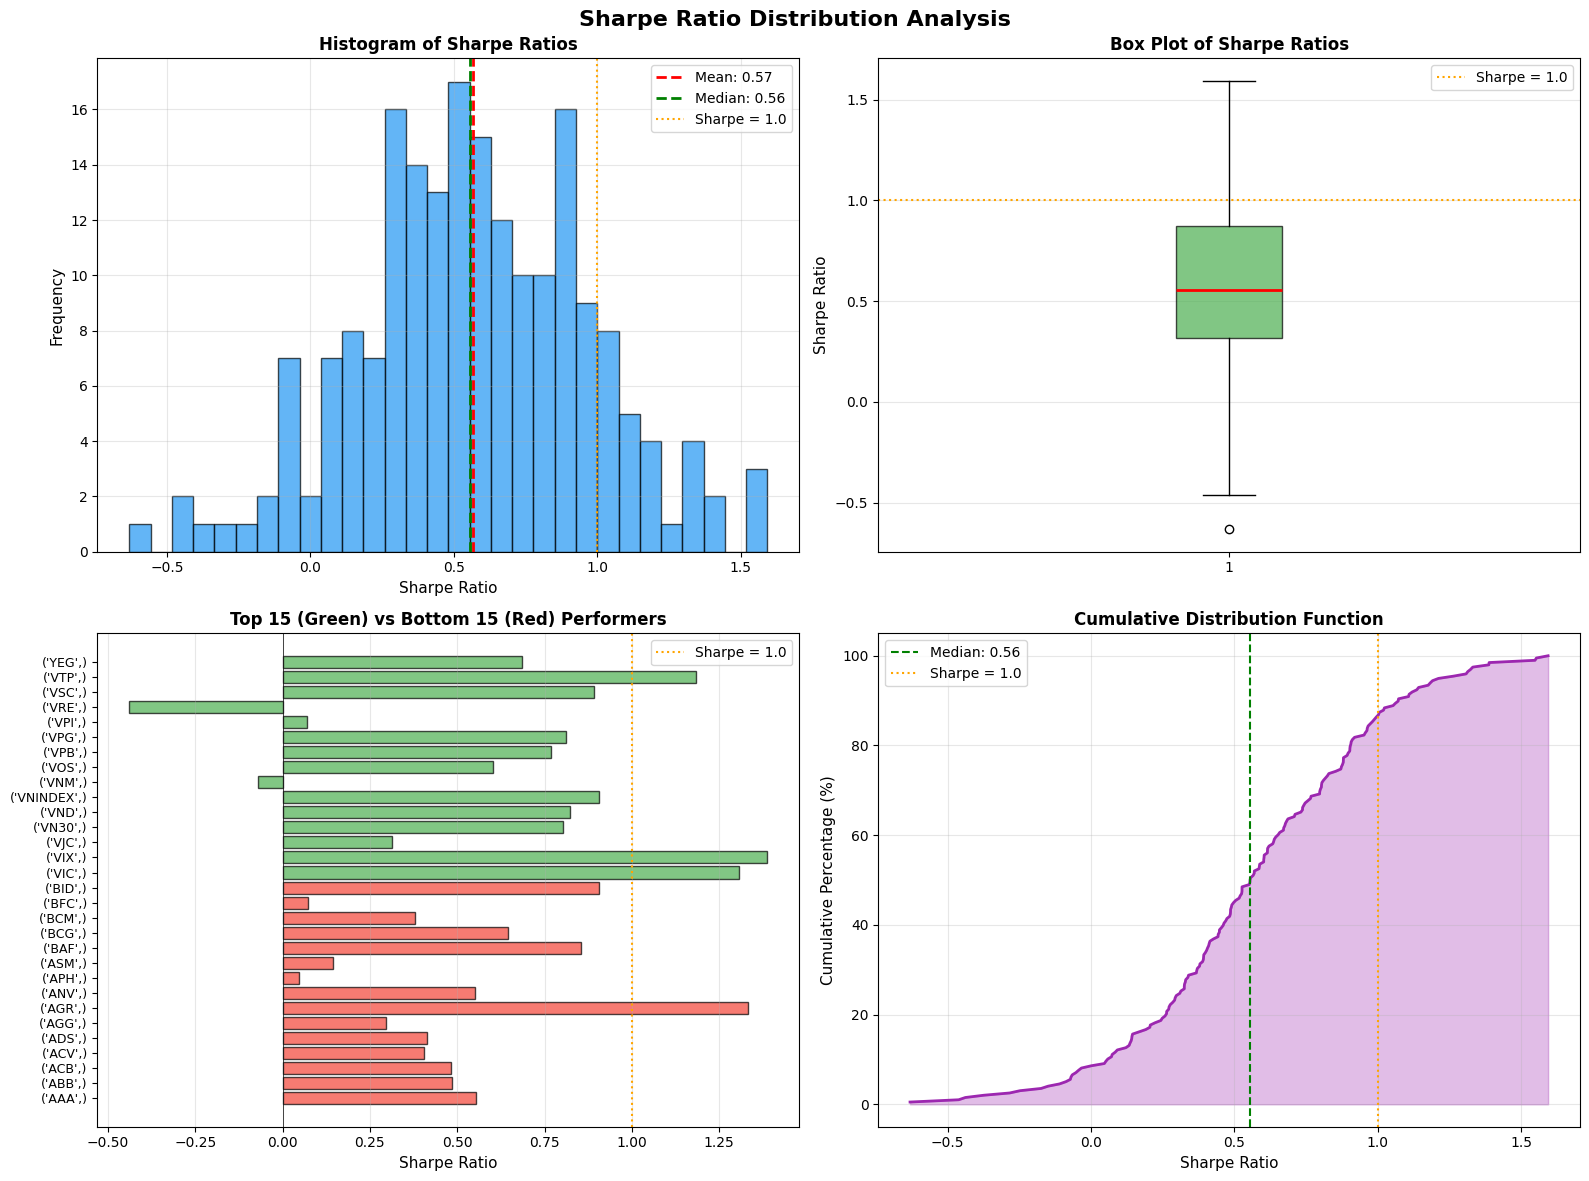


TOP 10 PERFORMERS (Highest Sharpe Ratio)
  ('VNINDEX',):   0.907
  ('VNM',):  -0.070
  ('VOS',):   0.602
  ('VPB',):   0.767
  ('VPG',):   0.810
  ('VPI',):   0.071
  ('VRE',):  -0.439
  ('VSC',):   0.893
  ('VTP',):   1.183
  ('YEG',):   0.686

BOTTOM 10 PERFORMERS (Lowest Sharpe Ratio)
  ('AAA',):   0.554
  ('ABB',):   0.486
  ('ACB',):   0.483
  ('ACV',):   0.406
  ('ADS',):   0.414
  ('AGG',):   0.297
  ('AGR',):   1.331
  ('ANV',):   0.551
  ('APH',):   0.046
  ('ASM',):   0.145


In [112]:
# Extract and plot Sharpe ratio distribution for each symbol
import matplotlib.pyplot as plt
import seaborn as sns

# Get stats grouped by symbol
sharpe_ratios = sharpe_best
print(f"Sharpe Ratio Statistics:")
print(f"  Mean: {sharpe_ratios.mean():.3f}")
print(f"  Median: {sharpe_ratios.median():.3f}")
print(f"  Std: {sharpe_ratios.std():.3f}")
print(f"  Min: {sharpe_ratios.min():.3f}")
print(f"  Max: {sharpe_ratios.max():.3f}")
print(f"\nSymbols with Sharpe > 1.0: {(sharpe_ratios > 1.0).sum()}")
print(f"Symbols with Sharpe > 2.0: {(sharpe_ratios > 2.0).sum()}")

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sharpe Ratio Distribution Analysis', fontsize=16, fontweight='bold')

# 1. Histogram
ax1 = axes[0, 0]
ax1.hist(sharpe_ratios.values, bins=30, edgecolor='black', alpha=0.7, color='#2196F3')
ax1.axvline(sharpe_ratios.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {sharpe_ratios.mean():.2f}')
ax1.axvline(sharpe_ratios.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {sharpe_ratios.median():.2f}')
ax1.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax1.set_xlabel('Sharpe Ratio', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Histogram of Sharpe Ratios', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Box Plot
ax2 = axes[0, 1]
bp = ax2.boxplot(sharpe_ratios.values, vert=True, patch_artist=True, 
                 boxprops=dict(facecolor='#4CAF50', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
ax2.axhline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax2.set_ylabel('Sharpe Ratio', fontsize=11)
ax2.set_title('Box Plot of Sharpe Ratios', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Top/Bottom performers bar chart
ax3 = axes[1, 0]
top_n = 15
top_symbols = sharpe_ratios.tail(top_n)
bottom_symbols = sharpe_ratios.head(top_n)
combined = pd.concat([bottom_symbols, top_symbols])
colors = ['#F44336'] * len(bottom_symbols) + ['#4CAF50'] * len(top_symbols)
ax3.barh(range(len(combined)), combined.values, color=colors, alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(combined)))
ax3.set_yticklabels(combined.index, fontsize=9)
ax3.axvline(0, color='black', linewidth=0.5)
ax3.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax3.set_xlabel('Sharpe Ratio', fontsize=11)
ax3.set_title(f'Top {top_n} (Green) vs Bottom {top_n} (Red) Performers', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='x')

# 4. Cumulative distribution
ax4 = axes[1, 1]
sorted_sharpe = np.sort(sharpe_ratios.values)
cumulative_pct = np.arange(1, len(sorted_sharpe) + 1) / len(sorted_sharpe) * 100
ax4.plot(sorted_sharpe, cumulative_pct, linewidth=2, color='#9C27B0')
ax4.axvline(sharpe_ratios.median(), color='green', linestyle='--', linewidth=1.5, label=f'Median: {sharpe_ratios.median():.2f}')
ax4.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax4.fill_between(sorted_sharpe, cumulative_pct, alpha=0.3, color='#9C27B0')
ax4.set_xlabel('Sharpe Ratio', fontsize=11)
ax4.set_ylabel('Cumulative Percentage (%)', fontsize=11)
ax4.set_title('Cumulative Distribution Function', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print top and bottom performers
print("\n" + "="*70)
print("TOP 10 PERFORMERS (Highest Sharpe Ratio)")
print("="*70)
for symbol, sharpe in sharpe_ratios.tail(10).items():
    print(f"  {symbol}: {sharpe:7.3f}")

print("\n" + "="*70)
print("BOTTOM 10 PERFORMERS (Lowest Sharpe Ratio)")
print("="*70)
for symbol, sharpe in sharpe_ratios.head(10).items():
    print(f"  {symbol}: {sharpe:7.3f}")

In [45]:
pf['VCG'].stats()


Start                         2016-01-29 00:00:00
End                           2026-01-27 00:00:00
Period                         2498 days 00:00:00
Start Value                                 100.0
End Value                              145.162453
Total Return [%]                        45.162453
Benchmark Return [%]                   295.209581
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        29.904678
Max Drawdown Duration           969 days 00:00:00
Total Trades                                   28
Total Closed Trades                            28
Total Open Trades                               0
Open Trade PnL                                0.0
Win Rate [%]                            35.714286
Best Trade [%]                          41.719561
Worst Trade [%]                         -7.665904
Avg Winning Trade [%]                   13.668687
Avg Losing Trade [%]                    -4.551421


In [ ]:
## Dual RSI strategy
df.close = df.close.round(2)
# Create writable copies of price data to avoid read-only array errors in vectorbt
close = df.close.copy()
high = df.high.copy()
low = df.low.copy()

## RSI from TA-lib
rsi_indicator = vbt.IndicatorFactory.from_talib('RSI')
rsi_df = rsi_indicator.run(df.close, timeperiod=[5, 14])
rsi5 = rsi_df.real.xs(5, level='rsi_timeperiod', axis=1)
rsi14 = rsi_df.real.xs(14, level='rsi_timeperiod', axis=1)

## Donchian Channel (Upper, Lower, Middle)
dc_channel = vbt.IndicatorFactory.from_pandas_ta('donchian', lower_indicators=['lowerband', 'upperband'])
dc_channel = dc_channel.run(high=high, low=low, lower_length=20, upper_length=20)

## AVWAP
vwap_indicator = vbt.IndicatorFactory(
    class_name='AVWAP',
    short_name='avwap',
    input_names=['close', 'high', 'low', 'volume'],
    param_names=['is_highest', 'window'],
    output_names=['avwap']
).from_apply_func(avwap_func_nb)

vwap = vwap_indicator.run(
    df.close, df.high, df.low, df.volume,
    is_highest=[True, False], window=200
).avwap

vwap_highest = vwap.xs(True, level='avwap_is_highest', axis=1)
vwap_lowest = vwap.xs(False, level='avwap_is_highest', axis=1)
# buy signal when rsi14 < 30 and prior 3-day consecutive rsi5 < 30 and rsi5 is decreasing
buy_signal = (
    (rsi14.shift(1) < 30) &
    (rsi5.shift(1).rolling(3).min() < 30) &
    (df.close > df.close.shift(1)) & (rsi5.shift(1) <= rsi5.shift(2)) & (rsi5.shift(2) <= rsi5.shift(3)) &
    # percentage from vwap & close > 10%
    (abs((df.close - vwap_highest.shift(1)) / vwap_highest.shift(1)) > 0.08)
)

sma20 = vbt.MA.run(close, window=20).ma

# sell_signal = df.high.vbt > dc_channel.dcu.shift(1).vbt
# sell_signal = df.high.vbt > sma20.vbt
sell_signal = df.high.vbt > vwap_highest.shift(1).vbt

pf = vbt.Portfolio.from_signals(
    close=df.close, 
    entries=buy_signal, 
    exits=sell_signal, 
    freq='1d', 
    group_by=['symbol'],
    sl_stop=0.05,  # 10% hard stop loss
)
pf.stats(group_by=True)

In [ ]:
## Optuna Multi-Objective Optimization for Dual RSI Strategy
## ===========================================================
## Optimizes for: Sharpe Ratio, Total Return, and Sortino Ratio
## Returns Pareto-optimal solutions (best trade-offs between objectives)

def create_multi_objective(df, rsi5, rsi14, vwap_highest, vwap_lowest, dc_channel, close, high, low):
    """Create the Optuna multi-objective function with data closure"""
    
    def objective(trial):
        # ═══════════════════════════════════════════════════════════════════════
        # BUY SIGNAL PARAMETERS
        # ═══════════════════════════════════════════════════════════════════════
        
        # RSI thresholds
        rsi14_threshold = trial.suggest_int("rsi14_threshold", 10, 20, step=1)
        rsi5_threshold = trial.suggest_int("rsi5_threshold", 3, 10, step=1)
        rsi5_rolling_window = trial.suggest_int("rsi5_rolling_window", 2, 5)
        
        # RSI5 decreasing streak (0 = disabled, 1-3 = number of consecutive decreasing days)
        # rsi5_decreasing_days = trial.suggest_int("rsi5_decreasing_days", 0, 3)
        rsi5_decreasing_days = 2
        # Price must be higher than previous close (on/off)
        # require_price_up = trial.suggest_categorical("require_price_up", [True, False])
        
        # VWAP distance threshold (0 = disabled)
        vwap_distance_pct = trial.suggest_float("vwap_distance_pct", 0.0, 0.15, step=0.02)
        
        # ═══════════════════════════════════════════════════════════════════════
        # SELL SIGNAL PARAMETERS
        # ═══════════════════════════════════════════════════════════════════════
        
        exit_type = trial.suggest_categorical("exit_type", ["vwap_highest", "vwap_lowest", "sma", "donchian"])
        sma_period = trial.suggest_int("sma_period", 10, 30, step=5) if exit_type == "sma" else 20
        
        # ═══════════════════════════════════════════════════════════════════════
        # PORTFOLIO PARAMETERS
        # ═══════════════════════════════════════════════════════════════════════
        
        sl_stop = trial.suggest_float("sl_stop", 0.03, 0.12, step=0.01)
        
        # ═══════════════════════════════════════════════════════════════════════
        # BUILD BUY SIGNAL
        # ═══════════════════════════════════════════════════════════════════════
        
        # Start with RSI14 condition (always required)
        buy_signal = (rsi14.shift(1) < rsi14_threshold)
        
        # RSI5 rolling condition
        buy_signal = buy_signal & (rsi5.shift(1).rolling(rsi5_rolling_window).min() < rsi5_threshold)
        
        # Price up condition (optional)
        # if require_price_up:
        buy_signal = buy_signal & (df.close > df.close.shift(1))
        
        # RSI5 decreasing streak (optional)
        if rsi5_decreasing_days >= 1:
            decreasing_cond = rsi5.shift(1) <= rsi5.shift(2)
            if rsi5_decreasing_days >= 2:
                decreasing_cond = decreasing_cond & (rsi5.shift(2) <= rsi5.shift(3))
            if rsi5_decreasing_days >= 3:
                decreasing_cond = decreasing_cond & (rsi5.shift(3) <= rsi5.shift(4))
            buy_signal = buy_signal & decreasing_cond
        
        # VWAP distance condition (optional)
        if vwap_distance_pct > 0:
            vwap_dist = abs((df.close - vwap_highest.shift(1)) / vwap_highest.shift(1))
            buy_signal = buy_signal & (vwap_dist > vwap_distance_pct)
        
        # ═══════════════════════════════════════════════════════════════════════
        # BUILD SELL SIGNAL
        # ═══════════════════════════════════════════════════════════════════════
        
        if exit_type == "vwap_highest":
            sell_signal = df.high.vbt > vwap_highest.shift(1).vbt
        elif exit_type == "vwap_lowest":
            sell_signal = df.high.vbt > vwap_lowest.shift(1).vbt
        elif exit_type == "sma":
            sma = vbt.MA.run(close, window=sma_period).ma
            sell_signal = df.high.vbt > sma.shift(1).vbt
        else:  # donchian
            sell_signal = df.high.vbt > dc_channel.dcu.shift(1).vbt
        
        # ═══════════════════════════════════════════════════════════════════════
        # RUN BACKTEST
        # ═══════════════════════════════════════════════════════════════════════
        
        try:
            pf = vbt.Portfolio.from_signals(
                close=df.close,
                entries=buy_signal,
                exits=sell_signal,
                freq='1d',
                group_by=['symbol'],
                sl_stop=sl_stop,
            )
            
            # Get portfolio-level stats
            stats = pf.stats(group_by=True)
            
            # ═══════════════════════════════════════════════════════════════════════
            # MULTI-OBJECTIVE: Sharpe Ratio, Total Return, Sortino Ratio
            # ═══════════════════════════════════════════════════════════════════════
            
            # Objective 1: Sharpe Ratio
            # sharpe = stats.get('Sharpe Ratio', np.nan)
            # if pd.isna(sharpe) or np.isinf(sharpe):
            #     sharpe = -10.0
            
            # Objective 2: Total Return
            total_return = stats.get('Total Return [%]', 0)
            if pd.isna(total_return) or np.isinf(total_return):
                total_return = -100.0
            
            # Objective 3: Sortino Ratio
            sortino = stats.get('Sortino Ratio', np.nan)
            if pd.isna(sortino) or np.isinf(sortino):
                sortino = -10.0
            
            # Secondary metrics for logging
            win_rate = stats.get('Win Rate [%]', 0)
            max_dd = stats.get('Max Drawdown [%]', 100)
            total_trades = stats.get('Total Trades', 0)
            
            # Penalize if too few trades (not statistically significant)
            trade_penalty = min(1.0, total_trades / 2000) if total_trades < 2000 else 1.0
            # sharpe = sharpe * trade_penalty
            sortino = sortino * trade_penalty
            total_return = total_return * trade_penalty
            
            # Log intermediate results
            trial.set_user_attr("total_return_raw", stats.get('Total Return [%]', 0))
            trial.set_user_attr("win_rate", win_rate)
            trial.set_user_attr("max_drawdown", max_dd)
            trial.set_user_attr("total_trades", total_trades)
            trial.set_user_attr("sharpe_raw", stats.get('Sharpe Ratio', np.nan))
            trial.set_user_attr("sortino_raw", stats.get('Sortino Ratio', np.nan))
            
            # Return tuple of objectives (all maximized)
            return total_return, sortino
            
        except Exception as e:
            print(f"Trial failed: {e}")
            return -100.0, -100.0
    
    return objective

# Create the multi-objective function
objective = create_multi_objective(df, rsi5, rsi14, vwap_highest, vwap_lowest, dc_channel, close, high, low)

# Create multi-objective study
# directions: maximize all three objectives
study = optuna.create_study(
    directions=["maximize", "maximize"],  # Sharpe, Total Return, Sortino
    study_name="dual_rsi_multi_objective",
    sampler=optuna.samplers.NSGAIISampler(seed=42),  # NSGA-II for multi-objective
)

# Run optimization (adjust n_trials as needed)
print("Starting Multi-Objective Optuna optimization...")
print("Objectives: Total Return, Sortino Ratio")
print("=" * 60)
study.optimize(objective, n_trials=1000, show_progress_bar=True)

# Display Pareto-optimal solutions
print("\n" + "=" * 60)
print("MULTI-OBJECTIVE OPTIMIZATION COMPLETE")
print("=" * 60)
print(f"\nFound {len(study.best_trials)} Pareto-optimal solutions")

# Create DataFrame of Pareto-optimal trials
pareto_data = []
for i, trial in enumerate(study.best_trials):
    pareto_data.append({
        'Trial': trial.number,
        # 'Sharpe': trial.values[0],
        'Total Return': trial.values[0],
        'Sortino': trial.values[1],
        'Win Rate': trial.user_attrs.get('win_rate', 0),
        'Max DD': trial.user_attrs.get('max_drawdown', 0),
        'Trades': trial.user_attrs.get('total_trades', 0),
        **trial.params
    })

pareto_df = pd.DataFrame(pareto_data)
print("\nPareto-Optimal Solutions (sorted by Total Return):")
display(pareto_df.sort_values('Total Return', ascending=False).head(10))


In [ ]:
pareto_df

In [ ]:
## Visualize Multi-Objective Optuna Results
## ==========================================

import optuna.visualization as vis

# Show Pareto front (2D projections)
print("Pareto Front Visualizations:")
print("=" * 60)

# Sharpe vs Total Return
try:
    fig_pareto_1 = optuna.visualization.plot_pareto_front(
        study, 
        target_names=["Sharpe Ratio", "Total Return", "Sortino Ratio"],
        targets=lambda t: (t.values[0], t.values[1])
    )
    fig_pareto_1.update_layout(title="Pareto Front: Sharpe Ratio vs Total Return")
    fig_pareto_1.show()
except Exception as e:
    print(f"Could not plot Pareto front (Sharpe vs Return): {e}")

# Sharpe vs Sortino
try:
    fig_pareto_2 = optuna.visualization.plot_pareto_front(
        study,
        target_names=["Sharpe Ratio", "Total Return", "Sortino Ratio"],
        targets=lambda t: (t.values[0], t.values[2])
    )
    fig_pareto_2.update_layout(title="Pareto Front: Sharpe Ratio vs Sortino Ratio")
    fig_pareto_2.show()
except Exception as e:
    print(f"Could not plot Pareto front (Sharpe vs Sortino): {e}")

# Show parameter importance for each objective
print("\nParameter Importance by Objective:")
for i, obj_name in enumerate(["Sharpe Ratio", "Total Return", "Sortino Ratio"]):
    try:
        fig_importance = optuna.visualization.plot_param_importances(
            study, 
            target=lambda t: t.values[i],
            target_name=obj_name
        )
        fig_importance.update_layout(title=f"Parameter Importance: {obj_name}")
        fig_importance.show()
    except Exception as e:
        print(f"Could not plot parameter importance for {obj_name}: {e}")

# Show parallel coordinate plot for Pareto-optimal trials
try:
    fig_parallel = optuna.visualization.plot_parallel_coordinate(
        study,
        targets=lambda t: t.values[0]  # Color by Sharpe Ratio
    )
    fig_parallel.update_layout(title="Parallel Coordinates (colored by Sharpe Ratio)")
    fig_parallel.show()
except Exception as e:
    print(f"Could not plot parallel coordinates: {e}")

# Full trials DataFrame
trials_df = study.trials_dataframe()
print("\nAll Trials Summary:")
print(f"Total trials: {len(trials_df)}")
print(f"Pareto-optimal trials: {len(study.best_trials)}")

# Show distribution of objectives
print("\nObjective Distributions:")
# print(f"Sharpe Ratio:  mean={trials_df['values_0'].mean():.3f}, max={trials_df['values_0'].max():.3f}")
print(f"Total Return:  mean={trials_df['values_0'].mean():.2f}%, max={trials_df['values_0'].max():.2f}%")
print(f"Sortino Ratio: mean={trials_df['values_1'].mean():.3f}, max={trials_df['values_1'].max():.3f}")


In [ ]:
# =============================================================================
# Optuna - Balanced Objective: Trades + Sharpe + Total Return
# =============================================================================

import optuna

# You can adjust these weights depending on your preference
WEIGHT_SHARPE = 0.5
WEIGHT_RETURN = 0.3
WEIGHT_TRADES = 0.2
TARGET_TRADES = 50  # target average trades per symbol


def objective_balanced(trial):
    # Parameter space (same as your strategy)
    demarker_period = trial.suggest_int('demarker_period', 10, 30)
    keltner_period = trial.suggest_int('keltner_period', 15, 30)
    bb_period = trial.suggest_int('bb_period', 15, 30)
    bb_deviation = trial.suggest_float('bb_deviation', 1.5, 3.0, step=0.1)
    keltner_factor = trial.suggest_float('keltner_factor', 1.0, 2.5, step=0.1)
    atr_multiplier = trial.suggest_float('atr_multiplier', 1.0, 3.0, step=0.1)
    sl_stop = trial.suggest_float('sl_stop', 0.05, 0.15, step=0.01)

    try:
        # --- Indicator & signals ---
        bb_demarker = bollinger_squeeze_demarker(
            high, low, close,
            demarker_period=demarker_period,
            keltner_period=keltner_period,
            bb_period=bb_period,
            bb_deviation=bb_deviation,
            keltner_factor=keltner_factor
        )

        buy_signal = (
            (bb_demarker['squeeze_on'].shift(1) & ~bb_demarker['squeeze_on']) &
            (bb_demarker['direction'] == 1)
        )

        atr_indicator = vbt.IndicatorFactory.from_talib("ATR").run(high, low, close, timeperiod=10)
        atr_scope = atr_indicator.real
        atr_trailing_indicator = vbt.IndicatorFactory(
            input_names=['close', 'atr'],
            param_names=['atr_multiplier'],
            output_names=['atr_trailing']
        ).from_apply_func(atr_trailing_nb)
        atr_sl = atr_trailing_indicator.run(close, atr_scope, atr_multiplier=atr_multiplier)
        sell_signal = close.vbt.crossed_below(atr_sl.atr_trailing)

        pf = vbt.Portfolio.from_signals(
            close=close,
            entries=buy_signal,
            exits=sell_signal,
            freq='1d',
            group_by=['symbol'],
            cash_sharing=False,
            sl_stop=sl_stop,
        )

        # --- Metrics ---
        sharpe = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
        total_ret = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
        trades = pf.trades.count().replace([np.inf, -np.inf], np.nan).dropna()

        if len(sharpe) == 0 or len(total_ret) == 0 or len(trades) == 0:
            return -100.0

        sharpe_mean = sharpe.mean()
        return_mean = total_ret.mean() * 100  # convert to %
        trades_mean = trades.mean()

        # Normalize components
        sharpe_score = np.tanh(sharpe_mean / 2.0)  # [-1, 1]
        return_score = np.tanh(return_mean / 50.0)  # scale return
        trades_score = min(trades_mean / TARGET_TRADES, 1.0)  # [0, 1]

        # Composite score
        score = (
            WEIGHT_SHARPE * sharpe_score +
            WEIGHT_RETURN * return_score +
            WEIGHT_TRADES * trades_score
        )

        # Log for inspection
        trial.set_user_attr('sharpe_mean', sharpe_mean)
        trial.set_user_attr('return_mean', return_mean)
        trial.set_user_attr('trades_mean', trades_mean)

        return score

    except Exception as e:
        print(f"Trial failed: {e}")
        return -100.0


print("Starting Optuna balanced optimization...")
study_balanced = optuna.create_study(direction='maximize')
study_balanced.optimize(objective_balanced, n_trials=1000, show_progress_bar=True)

print("\nBest balanced score:", study_balanced.best_value)
print("Best params:", study_balanced.best_params)

# Show best metrics
best_trial = study_balanced.best_trial
print("\nBest trial metrics:")
print("  Sharpe Mean:", best_trial.user_attrs.get('sharpe_mean'))
print("  Return Mean (%):", best_trial.user_attrs.get('return_mean'))
print("  Trades Mean:", best_trial.user_attrs.get('trades_mean'))

[I 2026-01-28 23:25:02,782] A new study created in memory with name: no-name-b54e669f-0e5f-440f-89e7-ca45c9202cf2


Starting Optuna balanced optimization...


  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2026-01-28 23:25:02,926] Trial 0 finished with value: 0.24966370855381936 and parameters: {'demarker_period': 22, 'keltner_period': 24, 'bb_period': 28, 'bb_deviation': 2.3, 'keltner_factor': 2.3, 'atr_multiplier': 2.8, 'sl_stop': 0.1}. Best is trial 0 with value: 0.24966370855381936.
[I 2026-01-28 23:25:03,023] Trial 1 finished with value: 0.13006443157824588 and parameters: {'demarker_period': 24, 'keltner_period': 26, 'bb_period': 22, 'bb_deviation': 2.7, 'keltner_factor': 1.7000000000000002, 'atr_multiplier': 2.1, 'sl_stop': 0.060000000000000005}. Best is trial 0 with value: 0.24966370855381936.
[I 2026-01-28 23:25:03,113] Trial 2 finished with value: 0.2631212778843932 and parameters: {'demarker_period': 24, 'keltner_period': 30, 'bb_period': 20, 'bb_deviation': 1.9, 'keltner_factor': 1.8, 'atr_multiplier': 1.5, 'sl_stop': 0.14}. Best is trial 2 with value: 0.2631212778843932.
[I 2026-01-28 23:25:03,202] Trial 3 finished with value: 0.21812216760525183 and parameters: {'demarke

In [ ]:
## Select and Apply Best Parameters from Pareto Front
## =====================================================
## Choose which Pareto-optimal solution to use based on your preference

# Strategy selection options:
# 1. "best_sharpe"  - Highest Sharpe Ratio (risk-adjusted returns)
# 2. "best_return"  - Highest Total Return (aggressive)
# 3. "best_sortino" - Highest Sortino Ratio (downside risk-adjusted)
# 4. "balanced"     - Best combined score (weighted average)

STRATEGY_SELECTION = "balanced"  # Change this to select different strategies

# Find best trial based on selection
if STRATEGY_SELECTION == "best_sharpe":
    best_trial = max(study.best_trials, key=lambda t: t.values[0])
    print("Selected: Best Sharpe Ratio strategy")
elif STRATEGY_SELECTION == "best_return":
    best_trial = max(study.best_trials, key=lambda t: t.values[1])
    print("Selected: Best Total Return strategy")
elif STRATEGY_SELECTION == "best_sortino":
    best_trial = max(study.best_trials, key=lambda t: t.values[2])
    print("Selected: Best Sortino Ratio strategy")
else:  # balanced
    # Normalize and combine objectives (equal weights)
    def combined_score(trial):
        # sharpe_norm = (trial.values[0] + 10) / 20  # Normalize ~[-10, 10] to [0, 1]
        return_norm = (trial.values[0] + 100) / 200  # Normalize ~[-100, 100] to [0, 1]
        sortino_norm = (trial.values[1] + 10) / 20  # Normalize ~[-10, 10] to [0, 1]
        return 0.4 * return_norm + 0.6 * sortino_norm
    best_trial = max(study.best_trials, key=combined_score)
    print("Selected: Balanced strategy (40% Return, 60% Sortino)")

best = best_trial.params

print(f"\nTrial #{best_trial.number}")
print(f"Objectives: Return={best_trial.values[0]:.2f}%, Sortino={best_trial.values[1]:.3f}")
print(f"\nParameters:")
for key, value in best.items():
    print(f"  {key}: {value}")

# Build optimized buy signal
opt_buy_signal = (rsi14.shift(1) < best['rsi14_threshold'])
opt_buy_signal = opt_buy_signal & (rsi5.shift(1).rolling(best['rsi5_rolling_window']).min() < best['rsi5_threshold'])

if best['rsi5_decreasing_days'] >= 1:
    decreasing_cond = rsi5.shift(1) <= rsi5.shift(2)
    if best['rsi5_decreasing_days'] >= 2:
        decreasing_cond = decreasing_cond & (rsi5.shift(2) <= rsi5.shift(3))
    if best['rsi5_decreasing_days'] >= 3:
        decreasing_cond = decreasing_cond & (rsi5.shift(3) <= rsi5.shift(4))
    opt_buy_signal = opt_buy_signal & decreasing_cond

if best['vwap_distance_pct'] > 0:
    vwap_dist = abs((df.close - vwap_highest.shift(1)) / vwap_highest.shift(1))
    opt_buy_signal = opt_buy_signal & (vwap_dist > best['vwap_distance_pct'])

# Build optimized sell signal
if best['exit_type'] == "vwap_highest":
    opt_sell_signal = df.high.vbt > vwap_highest.shift(1).vbt
elif best['exit_type'] == "vwap_lowest":
    opt_sell_signal = df.high.vbt > vwap_lowest.shift(1).vbt
elif best['exit_type'] == "sma":
    opt_sma = vbt.MA.run(close, window=best['sma_period']).ma
    opt_sell_signal = df.high.vbt > opt_sma.shift(1).vbt
else:  # donchian
    opt_sell_signal = df.high.vbt > dc_channel.dcu.shift(1).vbt

# Create optimized portfolio
pf_optimized = vbt.Portfolio.from_signals(
    close=df.close,
    entries=opt_buy_signal,
    exits=opt_sell_signal,
    freq='1d',
    group_by=['symbol'],
    sl_stop=best['sl_stop'],
)

print("\n" + "=" * 60)
print("OPTIMIZED PORTFOLIO STATS")
print("=" * 60)
pf_optimized.stats(group_by=True, metrics=[m for m in pf_optimized.metrics.keys() if m != 'profit_factor'])


In [ ]:
## Compare Original vs Optimized Strategy
## =======================================

# Per-symbol Sharpe Ratio comparison
original_sharpe = pf.sharpe_ratio()
optimized_sharpe = pf_optimized.sharpe_ratio()

comparison_df = pd.DataFrame({
    'Original Sharpe': original_sharpe,
    'Optimized Sharpe': optimized_sharpe,
    'Improvement': optimized_sharpe - original_sharpe
}).dropna()

print("Per-Symbol Sharpe Ratio Comparison (Top 20 by Improvement):")
display(comparison_df.sort_values('Improvement', ascending=False).head(20))

# Summary statistics
print("\n" + "=" * 60)
print("SUMMARY COMPARISON")
print("=" * 60)
print(f"Average Sharpe (Original):  {original_sharpe.mean():.4f}")
print(f"Average Sharpe (Optimized): {optimized_sharpe.mean():.4f}")
print(f"Improvement: {(optimized_sharpe.mean() - original_sharpe.mean()):.4f}")
print(f"\nSymbols with positive Sharpe (Original):  {(original_sharpe > 0).sum()}")
print(f"Symbols with positive Sharpe (Optimized): {(optimized_sharpe > 0).sum()}")


In [ ]:
pf.sharpe_ratio().sort_values(ascending=True)

In [ ]:
## Example: Using Matrix Series for trading signals

# Buy when: 
#   - up crosses above down (bullish)
#   - OR oversold signal (down < -200) and reversing
ms_buy_signal = (
    (ms['up'] > ms['down']) & (ms['up'].shift(1) <= ms['down'].shift(1))  # up crosses above down
) | (
    ms['oversold_signal'].shift(1) & (ms['up'] > ms['up'].shift(1))  # oversold and turning up
)

# Sell when:
#   - up crosses below down (bearish)  
#   - OR overbought signal (up > 200)
#   - OR CCI breaks below support line
ms_sell_signal = (
    (ms['up'] < ms['down']) & (ms['up'].shift(1) >= ms['down'].shift(1))  # up crosses below down
) | (
    ms['overbought_signal']  # overbought
) | (
    (ms['cci'] < ms['support']) & (ms['cci'].shift(1) >= ms['support'].shift(1))  # CCI breaks support
)

print(f"Buy signals: {ms_buy_signal.sum().sum()}")
print(f"Sell signals: {ms_sell_signal.sum().sum()}")

# You can now use these signals in Portfolio.from_signals:
# pf_ms = vbt.Portfolio.from_signals(
#     close=df.close,
#     entries=ms_buy_signal,
#     exits=ms_sell_signal,
#     freq='1d',
#     group_by=['symbol'],
#     sl_stop=0.05
# )


In [ ]:
import numba as nb

@nb.njit(cache=True)
def shannon_entropy_nb(arr, bins=10):
    """
    Numba-optimized Shannon entropy calculation.
    """
    n = len(arr)
    if n < 10:
        return np.nan
    
    # Find min/max for binning
    arr_min = arr[0]
    arr_max = arr[0]
    for i in range(n):
        if arr[i] < arr_min:
            arr_min = arr[i]
        if arr[i] > arr_max:
            arr_max = arr[i]
    
    # Handle edge case where all values are the same
    if arr_max == arr_min:
        return 0.0
    
    # Create histogram manually
    hist = np.zeros(bins, dtype=np.float64)
    bin_width = (arr_max - arr_min) / bins
    
    for i in range(n):
        bin_idx = int((arr[i] - arr_min) / bin_width)
        if bin_idx >= bins:
            bin_idx = bins - 1
        hist[bin_idx] += 1
    
    # Normalize to probabilities
    total = np.sum(hist)
    
    # Calculate entropy
    entropy_val = 0.0
    log2 = np.log(2.0)
    for i in range(bins):
        if hist[i] > 0:
            p = hist[i] / total
            entropy_val -= p * np.log(p) / log2
    
    return entropy_val

@nb.njit(parallel=True, cache=True)
def rolling_entropy_2d(data, window, bins=10):
    """
    Numba-optimized rolling entropy for 2D array (rows=time, cols=symbols).
    Uses parallel processing for speed.
    """
    n_rows, n_cols = data.shape
    result = np.full((n_rows, n_cols), np.nan)
    
    for col in nb.prange(n_cols):
        for row in range(window - 1, n_rows):
            window_data = data[row - window + 1:row + 1, col]
            # Check for NaN in window
            has_nan = False
            for i in range(window):
                if np.isnan(window_data[i]):
                    has_nan = True
                    break
            if not has_nan:
                result[row, col] = shannon_entropy_nb(window_data, bins)
    
    return result

# Calculate daily returns for each symbol
returns = df.close.pct_change()

# Convert to numpy array for numba processing
returns_arr = returns.values.astype(np.float64)

# Calculate rolling entropy using numba (MUCH faster!)
window = 20
bins = 10
entropy_arr = rolling_entropy_2d(returns_arr, window, bins)

# Convert back to DataFrame
entropy_df = pd.DataFrame(entropy_arr, index=returns.index, columns=returns.columns)

# Use a 1-year lookback for the historical average
threshold_window = 252
entropy_ma = entropy_df.rolling(window=threshold_window).mean()
entropy_std = entropy_df.rolling(window=threshold_window).std()
entropy_zscore = ((entropy_df - entropy_ma) / entropy_std).fillna(0)

print(f"Shannon Entropy per symbol (higher = more random):\n")
entropy_zscore.tail(50)


In [ ]:
sr = pf.sharpe_ratio().to_frame()
sr = sr.replace([np.inf, -np.inf], np.nan).dropna(subset=['sharpe_ratio'])
sr.sort_values(by='sharpe_ratio', ascending=False).plot.hist(bins=25, alpha=0.8)

In [ ]:
# Get list of all metrics and exclude "Profit Factor" to avoid read-only array bug
all_metrics = list(pf.metrics.keys())
metrics_to_use = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
pf_df = pf.stats(metrics=metrics_to_use)
# metrics_to_use
pf_df

## Save portfolio of the strategy into file

In [ ]:
# ============================================================================
# 1. Get all trades
# ============================================================================
all_trades_df = pf.trades.records_readable.copy()

# Robustly extract symbol: find element matching df.close.columns from Column tuple
close_symbols_set = set(df.close.columns)

def extract_symbol_from_column(col):
    # If tuple, look for entry that matches a symbol name
    if isinstance(col, tuple):
        for v in col:
            if v in close_symbols_set:
                return v
        # fallback: just string representation if not found
        return str(col)
    # If int, treat as index to columns
    elif isinstance(col, int):
        # Defensive: only if within length
        cols = list(df.close.columns)
        return cols[col] if 0 <= col < len(cols) else str(col)
    # If string, check if it's a symbol
    elif isinstance(col, str):
        return col if col in close_symbols_set else str(col)
    else:
        return str(col)

all_trades_df['symbol'] = all_trades_df['Column'].apply(extract_symbol_from_column)

# ============================================================================
# 2. Get stats for all symbols (agg_func=None returns stats per group/symbol)
# ============================================================================
all_metrics = list(pf.metrics.keys())
metrics_to_use = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
# metrics_to_use
all_stats_df = pf.stats(metrics=metrics_to_use, agg_func=None)

# Clean up symbol column (extract from tuple if needed)
all_stats_df = all_stats_df.reset_index().set_index('symbol')

# ============================================================================
# 3. Write to HDF5 file
# ============================================================================
h5_file = "../backend/assets/backtest_results.h5"


# Convert datetime to ISO string format (preserves correctly in HDF5 fixed format)
all_trades_df['Entry Timestamp'] = all_trades_df['Entry Timestamp'].dt.strftime('%Y-%m-%d')
all_trades_df['Exit Timestamp'] = all_trades_df['Exit Timestamp'].dt.strftime('%Y-%m-%d')

# Save trades
all_trades_df.to_hdf(h5_file, key='trades', mode='w')

# Save stats
all_stats_df.to_hdf(h5_file, key='stats', mode='a')

print(f"✓ Saved {len(all_trades_df)} trades to '{h5_file}' (key='trades')")
print(f"✓ Saved stats for {len(all_stats_df)} symbols to '{h5_file}' (key='stats')")

# Show sample
print("\n--- Stats columns available ---")
print(all_stats_df.columns.tolist())
all_trades_df.head()

In [ ]:
# Read trades
H5_BACKTEST_FILE = "../backend/assets/backtest_results.h5"
all_trades_df = pd.read_hdf(H5_BACKTEST_FILE, key='trades')

# Convert string dates back to datetime if needed
all_trades_df['Entry Timestamp'] = pd.to_datetime(all_trades_df['Entry Timestamp'])
all_trades_df['Exit Timestamp'] = pd.to_datetime(all_trades_df['Exit Timestamp'])
# all_trades_df[all_trades_df['symbol'] == 'AAA']
all_trades_df

In [ ]:
## Matrix Series Indicator (converted from PineScript)
## Original: http://www.wisestocktrader.com/indicators/2739-flower-indicator

def matrix_series_indicator(high, low, close, 
                             smoother=5, 
                             sup_res_period=50, 
                             sup_res_percentage=100, 
                             price_period=16,
                             overbought=200, 
                             oversold=-200):
    """
    Matrix Series Indicator - converted from PineScript.
    
    Returns:
        dict with keys: 'up', 'down', 'Oo', 'Hh', 'Ll', 'Cc', 
                       'resistance', 'support', 'overbought_signal', 'oversold_signal', 'color'
    """
    nn = smoother
    
    # Weighted close: (high + low + close * 2) / 4
    ys1 = (high + low + close * 2) / 4
    
    # EMA of ys1
    rk3 = ys1.ewm(span=nn, adjust=False).mean()
    
    # Standard deviation of ys1
    rk4 = ys1.rolling(window=nn).std()
    
    # Normalized deviation * 200
    rk5 = (ys1 - rk3) * 200 / rk4
    
    # Triple EMA smoothing
    rk6 = rk5.ewm(span=nn, adjust=False).mean()
    up = rk6.ewm(span=nn, adjust=False).mean()
    down = up.ewm(span=nn, adjust=False).mean()
    
    # Candle OHLC for plotting
    Oo = np.where(up < down, up, down)
    Hh = Oo.copy() if isinstance(Oo, np.ndarray) else Oo
    Ll = np.where(up < down, down, up)
    Cc = Ll.copy() if isinstance(Ll, np.ndarray) else Ll
    
    # Convert to DataFrame if needed
    if isinstance(up, pd.DataFrame):
        Oo = pd.DataFrame(Oo, index=up.index, columns=up.columns)
        Hh = pd.DataFrame(Hh, index=up.index, columns=up.columns)
        Ll = pd.DataFrame(Ll, index=up.index, columns=up.columns)
        Cc = pd.DataFrame(Cc, index=up.index, columns=up.columns)
    
    # Color: red if Oo > Cc, else green if up > down, else red
    color = np.where(Oo > Cc, 'red', np.where(up > down, 'green', 'red'))
    if isinstance(up, pd.DataFrame):
        color = pd.DataFrame(color, index=up.index, columns=up.columns)
    
    # ===== Support/Resistance Zones using CCI =====
    # CCI calculation: (close - SMA(close, n)) / (0.015 * Mean Deviation)
    sma_close = close.rolling(window=price_period).mean()
    mean_dev = close.rolling(window=price_period).apply(lambda x: np.abs(x - x.mean()).mean(), raw=True)
    cci = (close - sma_close) / (0.015 * mean_dev)
    
    # S/R calculation
    value2 = cci.rolling(window=sup_res_period).max()  # highest
    value3 = cci.rolling(window=sup_res_period).min()  # lowest
    value4 = value2 - value3
    value5 = value4 * (sup_res_percentage / 100)
    resistance_line = value3 + value5
    support_line = value2 - value5
    
    # ===== Overbought/Oversold Signals =====
    # UPshape: when up > overbought
    overbought_signal = (up > overbought)
    # DOWNshape: when down < oversold
    oversold_signal = (down < oversold)
    
    return {
        'up': up,
        'down': down,
        'Oo': Oo,
        'Hh': Hh,
        'Ll': Ll,
        'Cc': Cc,
        'color': color,
        'cci': cci,
        'resistance': resistance_line,
        'support': support_line,
        'overbought_signal': overbought_signal,
        'oversold_signal': oversold_signal,
    }

# Calculate Matrix Series for all symbols
ms = matrix_series_indicator(df.high, df.low, df.close)

print("Matrix Series Indicator calculated!")
print(f"Columns: {list(ms.keys())}")
ms['up'].tail()
